# Лабораторна робота №1. Дослідження напівпровідникових діодів

**Мета роботи:** ознайомитись з принципом дії, основними властивостями та застосуванням напівпровідникових діодів, дослідити вольт-амперні характеристики та визначити основні параметри напівпровідникових діодів.

У цьому зошиті лабораторна робота виконується шляхом SPICE-моделювання (PySpice + ngspice) — так само, як `Лб3_Біполярні_транзистори.ipynb`. Замість ручних побудов на роздрукованому графіку з документації пряма гілка ВАХ світлодіода моделюється, а розрахунки (баластний резистор, потужності, опір бази, контактна різниця потенціалів) виконуються чисельно.

**У цій версії використовується generic (узагальнена) SPICE-модель світлодіода**, а не точна модель приладу вашого варіанту: для більшості світлодіодів з додатку А готових SPICE-моделей немає. Модель будується за класичним рівнянням діода з опором бази і **калібрується за даними з документації** на ваш світлодіод (пряма напруга при заданому струмі, за можливості — друга точка ВАХ). Поки ці дані не внесено, використовуються типові значення для технології/кольору світіння, і зошит про це попереджає. Після внесення даних з документації всі розрахунки перераховуються автоматично.

## Короткі теоретичні відомості

**Ідеальна ВАХ** p-n переходу (вираз 2.22 методички) враховує лише інжекційну складову струму:

$$I = I_0\left(e^{U/\varphi_T}-1\right), \qquad \varphi_T=\frac{kT}{q}\approx 25{,}7\ \text{мВ (25 °C)},$$

де $I_0$ — тепловий струм діода. Контактна різниця потенціалів (2.8):

$$\varphi_к = \varphi_T \ln\frac{n_{n0}\,p_{p0}}{n_i^2}.$$

**Реальний діод** (вирази 2.23–2.25) відрізняється падінням напруги на опорі бази $r_б$ (і контактах), а також впливом рекомбінації в області переходу — його враховує коефіцієнт неідеальності $m$ (для світлодіодів $m\approx 2$):

$$U_{пр} = m\varphi_T \ln\left(\frac{I_{пр}}{I_0}+1\right) + I_{пр}\,r_б .$$

На **виродженій (лінійній) ділянці 2–3** прямої гілки (рис. 2.8) домінує другий доданок, тому:

* опір бази визначається через котангенс кута нахилу дотичної: $\;r_б = \operatorname{ctg}\varphi = \dfrac{\Delta U}{\Delta I}\Big|_{2-3}$;
* продовження дотичної 2–3 перетинає вісь напруг у точці 1 — це оцінка **контактної різниці потенціалів** $\varphi_к$ (напруги на самому p-n переході).

**Схема живлення світлодіода** — джерело $U_ж$, баластний резистор $R$ і світлодіод послідовно:

$$R = \frac{U_ж - U_{пр}}{I_{пр}}, \qquad P_R = I^2 R, \qquad P_{VD}=U_{пр} I, \qquad P_{спож} = U_ж I .$$

Номінал $R$ обирається з ряду E24, номінальна потужність резистора — з запасом (не менше ніж у 1,5 раза більша від $P_R$).

**Варіанти індивідуальних завдань (додаток А)** — варіант визначається порядковим номером у списку групи:

| Вар. | Світлодіод | Колір | $U_ж$, В | $I_{пр}$, мА | Документація |
|---|---|---|---|---|---|
| 1 | Kingbright W53SRC/E | червоний | 3,3 | 20 | http://www.farnell.com/datasheets/3153.pdf |
| 2 | Kingbright L-1334IT | червоний | 3,3 | 20 | http://www.farnell.com/datasheets/1446111.pdf |
| 3 | Osram LR E6SF-V2AB-1-1 | червоний | 5,0 | 30 | http://www.farnell.com/datasheets/43531.pdf |
| 4 | Vishay TLHR5400 | червоний | 3,3 | 10 | http://www.farnell.com/datasheets/6606.pdf |
| 5 | Kingbright KT-2520ZG10ZS | зелений | 5,0 | 300 | http://www.kingbright-europe.de/_daten/KT-2520ZG10ZS-RV(Ver.3).pdf |
| 6 | CREE CLM4B-GKW-CWBYA693 | зелений | 6,0 | 60 | http://www.farnell.com/datasheets/1830328.pdf |
| 7 | VCC VAOL-5GDE4 | зелений | 3,3 | 30 | http://www.farnell.com/datasheets/789168.pdf |
| 8 | Avago ASMT-UGB5-NV702 | зелений | 4,0 | 15 | http://www.farnell.com/datasheets/1328637.pdf |
| 9 | Avago ASMT-SBB5-NT703 | синій | 5,0 | 20 | http://www.farnell.com/datasheets/1328634.pdf |
| 10 | CREE C503B-BAS | синій | 5,0 | 50 | http://www.farnell.com/datasheets/1604976.pdf |
| 11 | Wurth 151051BS04000 | синій | 3,5 | 20 | http://katalog.we-online.de/led/datasheet/151051BS04000.pdf |
| 12 | Avago ASMT-QAB2-FDE0E | бурштиновий | 7,0 | 160 | http://www.farnell.com/datasheets/1444605.pdf |
| 13 | Vishay VLMK71ABAD-GS08 | бурштиновий | 3,3 | 400 | http://www.farnell.com/datasheets/32303.pdf |
| 14 | Kingbright KT-2520SY9ZS-RV | жовтий | 5,5 | 300 | http://www.kingbright-europe.de/_daten/KT-2520SY9ZS-RV(Ver.3).pdf |
| 15 | Avago HLMP-0401 | жовтий | 6,0 | 60 | http://www.farnell.com/datasheets/1825508.pdf |
| 16 | Avago HLMP-3401 | жовтий | 3,3 | 20 | http://www.farnell.com/datasheets/1825529.pdf |
| 17 | AND AND520HW | білий | 7,0 | 30 | http://www.farnell.com/datasheets/117649.pdf |
| 18 | Bridgelux BXRA-C0402 (LED-матриця) | білий | 12,0 | 500 | http://www.farnell.com/datasheets/579585.pdf |
| 19 | CREE C535A-WJN | білий | 5,0 | 20 | http://www.farnell.com/datasheets/1801225.pdf |
| 20 | Optec OVLAW4CB7 | білий | 5,0 | 25 | http://www.farnell.com/datasheets/1643142.pdf |

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')   # конфлікт системного і pip-matplotlib, на роботу не впливає
import logging
logging.getLogger('PySpice').setLevel(logging.CRITICAL)   # приховує інформаційні повідомлення ngspice ("Using SPARSE...", "Unsupported Ngspice version")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

import schemdraw
import schemdraw.elements as elm
elm.style(elm.STYLE_IEC)   # умовні позначення за ДСТУ/IEC (резистор — прямокутник)

%matplotlib inline

## Вихідні дані варіанту

Вкажіть свій номер варіанту `VARIANT` (порядковий номер у списку групи).

In [2]:
VARIANT = 1   # <-- ваш варіант (1..20)

#           світлодіод                    колір          Uж, В  Iпр, А
VARIANTS = {
    1:  ('Kingbright W53SRC/E',          'червоний',     3.3,  20e-3),
    2:  ('Kingbright L-1334IT',          'червоний',     3.3,  20e-3),
    3:  ('Osram LR E6SF-V2AB-1-1',       'червоний',     5.0,  30e-3),
    4:  ('Vishay TLHR5400',              'червоний',     3.3,  10e-3),
    5:  ('Kingbright KT-2520ZG10ZS',     'зелений',      5.0, 300e-3),
    6:  ('CREE CLM4B-GKW-CWBYA693',      'зелений',      6.0,  60e-3),
    7:  ('VCC VAOL-5GDE4',               'зелений',      3.3,  30e-3),
    8:  ('Avago ASMT-UGB5-NV702',        'зелений',      4.0,  15e-3),
    9:  ('Avago ASMT-SBB5-NT703',        'синій',        5.0,  20e-3),
    10: ('CREE C503B-BAS',               'синій',        5.0,  50e-3),
    11: ('Wurth 151051BS04000',          'синій',        3.5,  20e-3),
    12: ('Avago ASMT-QAB2-FDE0E',        'бурштиновий',  7.0, 160e-3),
    13: ('Vishay VLMK71ABAD-GS08',       'бурштиновий',  3.3, 400e-3),
    14: ('Kingbright KT-2520SY9ZS-RV',   'жовтий',       5.5, 300e-3),
    15: ('Avago HLMP-0401',              'жовтий',       6.0,  60e-3),
    16: ('Avago HLMP-3401',              'жовтий',       3.3,  20e-3),
    17: ('AND AND520HW',                 'білий',        7.0,  30e-3),
    18: ('Bridgelux BXRA-C0402',         'білий',       12.0, 500e-3),
    19: ('CREE C535A-WJN',               'білий',        5.0,  20e-3),
    20: ('Optec OVLAW4CB7',              'білий',        5.0,  25e-3),
}

LED_NAME, COLOR, Vcc, I_led = VARIANTS[VARIANT]
print(f'Варіант {VARIANT}: {LED_NAME} ({COLOR}),  Uж = {Vcc} В,  Iпр = {I_led * 1e3:g} мА')

Варіант 1: Kingbright W53SRC/E (червоний),  Uж = 3.3 В,  Iпр = 20 мА


### Дані з документації на світлодіод

Знайдіть у документації (посилання — в таблиці варіантів) і занесіть сюди:

* `Vf1`, `If1` — типова пряма напруга $U_{пр}$ при струмі $I_{пр}$ (таблиця *Electrical/Optical Characteristics*, параметр *Forward Voltage, typ*);
* `Vf2`, `If2` — (бажано) ще одна точка прямої гілки ВАХ з графіка *Forward Current vs. Forward Voltage* при більшому струмі — за двома точками модель відтворює і нахил ВАХ (опір бази);
* `Iv`, `Iv_If` — сила світла (мкд) або світловий потік (лм) та струм, при якому вона нормована;
* `wavelength` — домінантна довжина хвилі, нм (для білих — колірна температура, К);
* `dVf_dT` — температурний коефіцієнт прямої напруги, В/°C (якщо наведений; типово −1,5…−2,5 мВ/°C).

Якщо значення невідоме — залиште `None`: буде використано типове значення для технології, а зошит виведе попередження.

In [3]:
# TODO: підставте дані з документації на СВІЙ світлодіод
Vf1, If1 = None, None        # В, А   — типова пряма напруга при струмі If1
Vf2, If2 = None, None        # В, А   — друга точка прямої гілки ВАХ (з графіка)
Iv, Iv_If = None, None       # мкд (або лм), А — сила світла / світловий потік при струмі Iv_If
wavelength = None            # нм (для білих — колірна температура, К)
dVf_dT = None                # В/°C — температурний коефіцієнт прямої напруги (якщо наведений)

## Модель світлодіода

SPICE-модель діода описує пряму гілку тим самим рівнянням, що й теорія: $U = N\varphi_T\ln(I/I_S+1) + I\cdot R_S$, де `IS` $=I_0$, `N` $=m$, `RS` $=r_б$. Модель калібрується так:

* `N = 2` — типовий коефіцієнт неідеальності світлодіодів (переважає рекомбінаційний струм);
* за **двома** точками ВАХ з документації розв'язується система з двох рівнянь відносно `RS` і `IS`; за **однією** точкою `RS` береться типовим ($\approx 0{,}15\ \text{В}/I_{пр}$), а `IS` підбирається так, щоб при $I_{пр}$ напруга дорівнювала $U_{пр}$;
* `EG` (ширина забороненої зони, еВ) — з кольору світіння ($E_g\approx hc/\lambda$), а показник `XTI` температурної залежності $I_0$ підбирається так, щоб температурний коефіцієнт прямої напруги дорівнював `dVf_dT` з документації (типово −1,8 мВ/°C). Ці два параметри визначають лише температурну залежність ВАХ.

Типові значення $U_{пр}$ (якщо дані з документації ще не внесено): AlInGaP/GaAsP (червоні, бурштинові, жовті) — 2,0–2,1 В, InGaN (зелені, сині, білі) — 3,2 В.

**Важливо (типова пастка PySpice/ngspice, див. Лб3):** значення струмів задаються звичайними числами в амперах (`20e-3`), а не `20@u_mA`/`0.02@u_A` — інакше в netlist потрапляє `0.02A`, а ngspice прочитає самотню `A` як префікс *atto* ($10^{-18}$).

In [4]:
PHI_T = 1.380649e-23 * 298.15 / 1.602176634e-19   # В, тепловий потенціал при 25 °C
N_LED = 2.0

#            типова Uпр, В   Eg, еВ (≈ hc/λ)
TECH = {'червоний':    (2.0, 1.95),
        'бурштиновий': (2.1, 2.05),
        'жовтий':      (2.1, 2.10),
        'зелений':     (3.2, 2.35),
        'синій':       (3.2, 2.70),
        'білий':       (3.2, 2.70)}


def led_model_params():
    """Параметри generic-моделі світлодіода за даними документації (або типовими)."""
    vf_typ, eg = TECH[COLOR]
    v1, i1 = (Vf1, If1) if Vf1 is not None else (vf_typ, I_led)
    if Vf1 is None:
        print(f'Увага: Vf1 не задано — використано типове значення Uпр = {vf_typ} В '
              f'при {I_led * 1e3:g} мА для кольору "{COLOR}". Замініть даними з документації!')
    if Vf2 is not None:
        rs = ((Vf2 - v1) - N_LED * PHI_T * np.log(If2 / i1)) / (If2 - i1)
        rs = max(rs, 0.0)
    else:
        rs = 0.15 / I_led
    i_s = i1 / np.exp((v1 - i1 * rs) / (N_LED * PHI_T))
    # dUпер/dT ~= (Uпер - Eg - XTI*φT)/T  ->  XTI, що дає заданий температурний коефіцієнт
    tc = dVf_dT if dVf_dT is not None else -1.8e-3
    xti = (v1 - i1 * rs - eg - tc * 298.15) / PHI_T
    return dict(IS=i_s, N=N_LED, RS=rs, EG=eg, XTI=xti, BV=5, IBV=10e-6)


def add_led(circuit, anode, cathode):
    circuit.model('LED', 'D', **LED_PARAMS)
    circuit.D(1, anode, cathode, model='LED')


def led_forward_iv(i_max, temperature=25, n_points=1000):
    """Пряма гілка ВАХ: розгортка джерела прямого струму IF (аналог IS1 в TINA)."""
    circuit = Circuit('LED forward IV')
    circuit.I('F', circuit.gnd, 'anode', 0)          # струм втікає в анод
    add_led(circuit, 'anode', circuit.gnd)
    simulator = circuit.simulator(temperature=temperature, nominal_temperature=25)
    analysis = simulator.dc(IF=slice(0, i_max, i_max / n_points))
    return np.array(analysis.sweep), np.array(analysis.anode)


def led_supply_op(vcc, r):
    """Робоча точка схеми живлення: Uж - R - світлодіод."""
    circuit = Circuit('LED supply')
    circuit.V('CC', 'vcc', circuit.gnd, vcc)
    circuit.R(1, 'vcc', 'anode', r)
    add_led(circuit, 'anode', circuit.gnd)
    analysis = circuit.simulator(temperature=25, nominal_temperature=25).operating_point()
    v_led = float(np.array(analysis.anode)[0])
    return v_led, (vcc - v_led) / r


LED_PARAMS = led_model_params()
print('Параметри моделі:', ', '.join(f'{k}={v:.4g}' for k, v in LED_PARAMS.items()))

Увага: Vf1 не задано — використано типове значення Uпр = 2.0 В при 20 мА для кольору "червоний". Замініть даними з документації!
Параметри моделі: IS=4.627e-18, N=2, RS=7.5, EG=1.95, XTI=17, BV=5, IBV=1e-05


## Проведення досліджень

### 1. Розрахунок схеми живлення світлодіода

In [5]:
I_sweep, V_sweep = led_forward_iv(i_max=2.5 * I_led)
Vf_at_I = np.interp(I_led, I_sweep, V_sweep)          # Uпр при заданому струмі (за моделлю)

R_calc = (Vcc - Vf_at_I) / I_led
if R_calc <= 0:
    raise ValueError(f'Uж = {Vcc} В не перевищує Uпр = {Vf_at_I:.2f} В — світлодіод не можна '
                     'живити через резистор. Перевірте Uпр з документації (для LED-матриць вона значно більша).')

E24 = np.array([1.0, 1.1, 1.2, 1.3, 1.5, 1.6, 1.8, 2.0, 2.2, 2.4, 2.7, 3.0,
                3.3, 3.6, 3.9, 4.3, 4.7, 5.1, 5.6, 6.2, 6.8, 7.5, 8.2, 9.1])


def e24_ceil(r):
    """Найближчий номінал ряду E24, не менший за r (щоб струм не перевищив заданий)."""
    decade = 10 ** np.floor(np.log10(r))
    for k in (1, 10):
        cand = E24 * decade * k
        cand = cand[cand >= r * (1 - 1e-9)]
        if len(cand):
            return float(cand[0])


P_RATINGS = [0.125, 0.25, 0.5, 1, 2, 5, 10]
R_e24 = e24_ceil(R_calc)
V_led, I_real = led_supply_op(Vcc, R_e24)               # SPICE-перевірка з обраним номіналом
P_R = I_real ** 2 * R_e24
P_R_nom = next(p for p in P_RATINGS if p >= 1.5 * P_R)
P_led = V_led * I_real
P_total = Vcc * I_real

print(f'Uпр при {I_led*1e3:g} мА (модель)    = {Vf_at_I:.3f} В')
print(f'Розрахунковий опір R = (Uж-Uпр)/Iпр = {R_calc:.2f} Ом  ->  номінал E24: {R_e24:g} Ом')
print(f'Струм з обраним R (SPICE)         = {I_real*1e3:.2f} мА,  Uпр = {V_led:.3f} В')
print(f'Потужність на резисторі P_R       = {P_R*1e3:.1f} мВт  ->  резистор {P_R_nom:g} Вт')
print(f'Потужність на світлодіоді P_VD    = {P_led*1e3:.1f} мВт')
print(f'Споживана схемою потужність       = {P_total*1e3:.1f} мВт  (ККД ~ {P_led/P_total*100:.0f} %)')

Uпр при 20 мА (модель)    = 2.000 В
Розрахунковий опір R = (Uж-Uпр)/Iпр = 65.00 Ом  ->  номінал E24: 68 Ом
Струм з обраним R (SPICE)         = 19.23 мА,  Uпр = 1.992 В
Потужність на резисторі P_R       = 25.2 мВт  ->  резистор 0.125 Вт
Потужність на світлодіоді P_VD    = 38.3 мВт
Споживана схемою потужність       = 63.5 мВт  (ККД ~ 60 %)


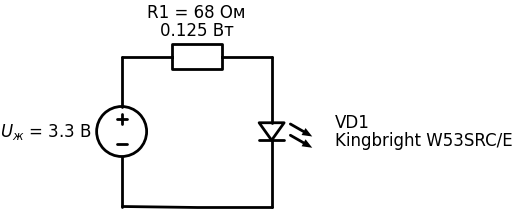

In [6]:
# Схема живлення світлодіода (рис. до п. 1 звіту)
with schemdraw.Drawing() as d:
    d.config(fontsize=12, unit=3)
    src = elm.SourceV().up().label(f'$U_ж$ = {Vcc:g} В')
    elm.Resistor().right().label(f'R1 = {R_e24:g} Ом\n{P_R_nom:g} Вт')
    elm.LED().down().label(f'VD1\n{LED_NAME}', loc='bottom', ofst=0.3)
    elm.Line().left().tox(src.start)

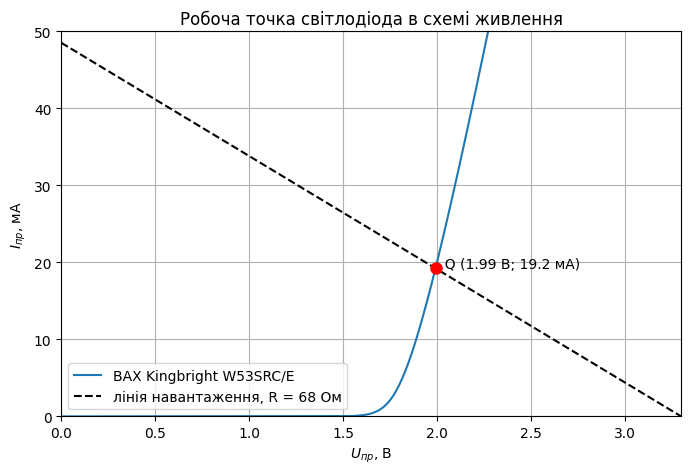

In [7]:
# Графічна перевірка: робоча точка = перетин ВАХ світлодіода з лінією навантаження I = (Uж - U)/R
u_line = np.linspace(0, Vcc, 200)
plt.figure(figsize=(8, 5))
plt.plot(V_sweep, I_sweep * 1e3, label=f'ВАХ {LED_NAME}')
plt.plot(u_line, (Vcc - u_line) / R_e24 * 1e3, 'k--', label=f'лінія навантаження, R = {R_e24:g} Ом')
plt.plot(V_led, I_real * 1e3, 'ro', ms=8)
plt.annotate(f'  Q ({V_led:.2f} В; {I_real*1e3:.1f} мА)', (V_led, I_real * 1e3))
plt.xlim(0, Vcc)
plt.ylim(0, 2.5 * I_led * 1e3)
plt.xlabel('$U_{пр}$, В')
plt.ylabel('$I_{пр}$, мА')
plt.title('Робоча точка світлодіода в схемі живлення')
plt.legend()
plt.grid(True)
plt.show()

**Сила світла та колір світіння.** У межах робочих струмів сила світла (світловий потік) приблизно пропорційна струму: $I_V(I)\approx I_{V,ном}\cdot I/I_{ном}$. Точніше — за графіком *Relative Luminous Intensity vs. Forward Current* з документації.

In [8]:
if Iv is not None:
    print(f'Сила світла при {I_real*1e3:.1f} мА ~= {Iv * I_real / Iv_If:.1f} (лінійна апроксимація від {Iv:g} при {Iv_If*1e3:g} мА)')
else:
    print('Iv не задано — внесіть силу світла з документації в комірку "Дані з документації".')
print(f'Колір світіння: {COLOR}' + (f',  λ = {wavelength:g} нм' if wavelength else ''))

Iv не задано — внесіть силу світла з документації в комірку "Дані з документації".
Колір світіння: червоний


### 2. Визначення опору бази та контактної різниці потенціалів

У документації пряма гілка ВАХ часто наведена в **логарифмічному** масштабі по струму. Для графоаналітичного методу (рис. 2.8, 2.12) її потрібно перебудувати у **звичайному (лінійному)** масштабі — нижче показано обидва варіанти.

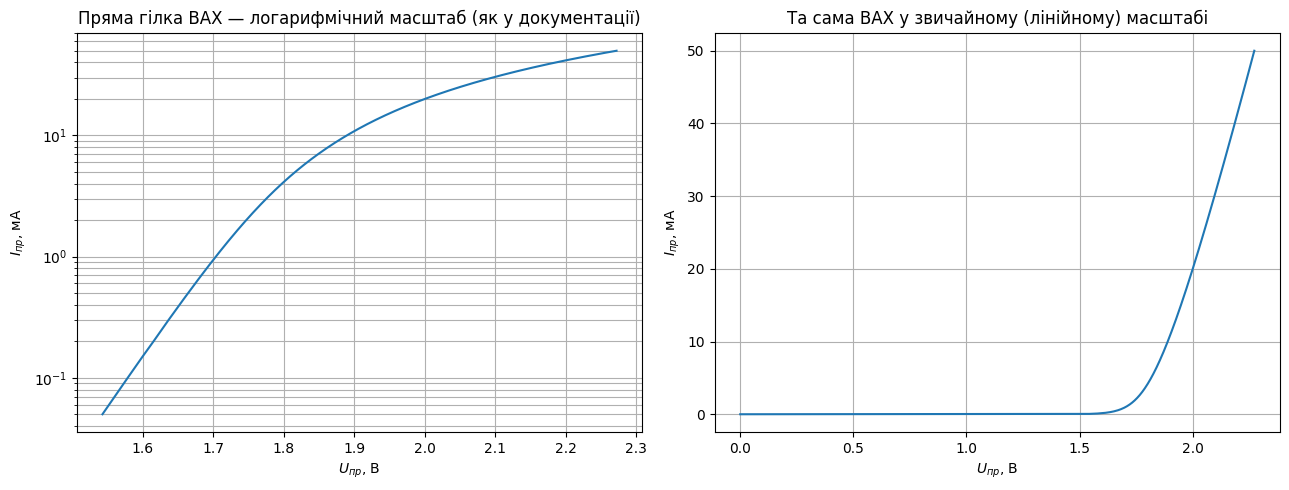

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
ax.semilogy(V_sweep[1:], I_sweep[1:] * 1e3)
ax.set_xlabel('$U_{пр}$, В'); ax.set_ylabel('$I_{пр}$, мА')
ax.set_title('Пряма гілка ВАХ — логарифмічний масштаб (як у документації)')
ax.grid(True, which='both')

ax = axes[1]
ax.plot(V_sweep, I_sweep * 1e3)
ax.set_xlabel('$U_{пр}$, В'); ax.set_ylabel('$I_{пр}$, мА')
ax.set_title('Та сама ВАХ у звичайному (лінійному) масштабі')
ax.grid(True)
plt.tight_layout()
plt.show()

Замість ручного проведення дотичної — чисельний аналог методу: через дві точки **2** і **3** на виродженій (лінійній) ділянці проводиться пряма, її котангенс кута нахилу дає $r_б$, а перетин з віссю напруг (точка **1**) — $\varphi_к$. За замовчуванням точка 2 береться при $I_{пр}$ вашого варіанту, точка 3 — при $2{,}5\,I_{пр}$.

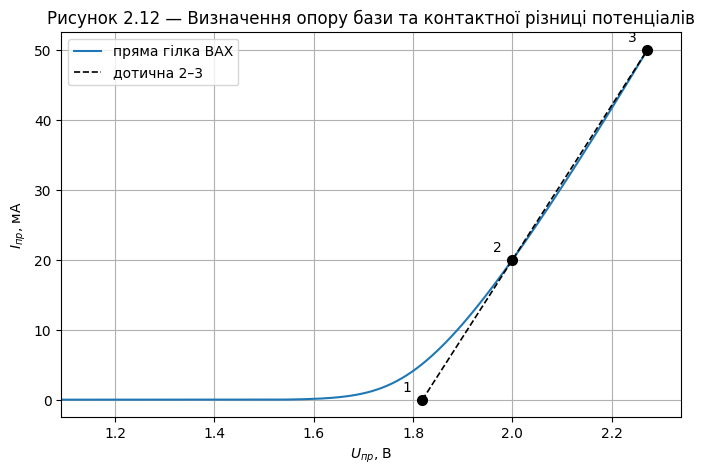

Опір бази          r_б  = ΔU/ΔI = 9.069 Ом
Контактна різниця  φк   ~= 1.819 В   (порівняйте з Eg/q = 1.95 В)


In [10]:
def base_resistance(i2, i3):
    """Дотична (січна) 2-3 на лінійній ділянці: r_б = ΔU/ΔI, φк — відсічка на осі напруг (точка 1)."""
    u2, u3 = np.interp(i2, I_sweep, V_sweep), np.interp(i3, I_sweep, V_sweep)
    rb = (u3 - u2) / (i3 - i2)
    phi_k = u2 - rb * i2
    return rb, phi_k, u2, u3


def plot_tangent(i2, i3, ax):
    rb, phi_k, u2, u3 = base_resistance(i2, i3)
    ax.plot(V_sweep, I_sweep * 1e3, label='пряма гілка ВАХ')
    i_line = np.linspace(0, I_sweep[-1], 50)
    ax.plot(phi_k + rb * i_line, i_line * 1e3, 'k--', lw=1.2, label='дотична 2–3')
    for (u, i, name) in [(phi_k, 0, '1'), (u2, i2, '2'), (u3, i3, '3')]:
        ax.plot(u, i * 1e3, 'ko', ms=7)
        ax.annotate(name, (u, i * 1e3), textcoords='offset points', xytext=(-14, 6))
    ax.set_xlim(0.6 * phi_k, V_sweep[-1] * 1.03)
    ax.set_xlabel('$U_{пр}$, В'); ax.set_ylabel('$I_{пр}$, мА')
    ax.legend(); ax.grid(True)
    return rb, phi_k


I2, I3 = I_led, 2.5 * I_led
fig, ax = plt.subplots(figsize=(8, 5))
r_b, phi_k = plot_tangent(I2, I3, ax)
ax.set_title('Рисунок 2.12 — Визначення опору бази та контактної різниці потенціалів')
plt.show()

print(f'Опір бази          r_б  = ΔU/ΔI = {r_b:.3f} Ом')
print(f'Контактна різниця  φк   ~= {phi_k:.3f} В   (порівняйте з Eg/q = {LED_PARAMS["EG"]:.2f} В)')

### Фізична перевірка $r_б$

Дотична 2–3 проводиться не на ідеально прямій ділянці: диференціальний опір діода

$$r_{диф}=\frac{dU}{dI} = \frac{m\varphi_T}{I} + r_б$$

містить ще й «експоненційний» доданок $m\varphi_T/I$, який зменшується зі зростанням струму, але не зникає. Тому графоаналітична оцінка $r_б$ завжди **трохи більша** за опір бази `RS`, закладений у модель, і тим ближча до нього, чим більші струми точок 2 і 3. Контактна різниця потенціалів p-n переходу менша за ширину забороненої зони ($q\varphi_к < E_g$), тому для AlInGaP/GaAsP світлодіодів (червоні, бурштинові, жовті) відсічка дотичної отримується трохи меншою за $E_g/q\approx hc/(q\lambda)$. У InGaN-світлодіодах (зелені, сині, білі) пряма напруга помітно перевищує енергію фотона через додаткові гетеробар'єри та опір шару p-GaN, і оцінка $\varphi_к$ може виявитися більшою за $hc/(q\lambda)$.

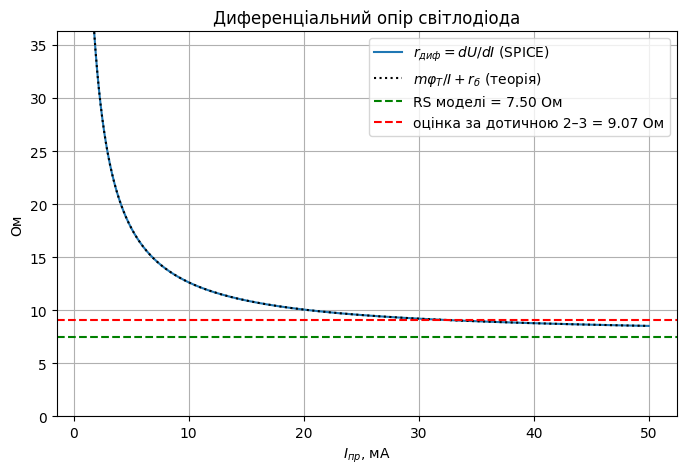

Похибка оцінки r_б відносно RS моделі: 21 %


In [11]:
r_diff = np.gradient(V_sweep, I_sweep)
mask = I_sweep > 0.05 * I_led
plt.figure(figsize=(8, 5))
plt.plot(I_sweep[mask] * 1e3, r_diff[mask], label='$r_{диф}=dU/dI$ (SPICE)')
plt.plot(I_sweep[mask] * 1e3, N_LED * PHI_T / I_sweep[mask] + LED_PARAMS['RS'], 'k:', label=r'$m\varphi_T/I + r_б$ (теорія)')
plt.axhline(LED_PARAMS['RS'], color='g', ls='--', label=f'RS моделі = {LED_PARAMS["RS"]:.2f} Ом')
plt.axhline(r_b, color='r', ls='--', label=f'оцінка за дотичною 2–3 = {r_b:.2f} Ом')
plt.ylim(0, 4 * r_b)
plt.xlabel('$I_{пр}$, мА'); plt.ylabel('Ом')
plt.title('Диференціальний опір світлодіода')
plt.legend(); plt.grid(True)
plt.show()
print(f'Похибка оцінки r_б відносно RS моделі: {(r_b / LED_PARAMS["RS"] - 1) * 100 if LED_PARAMS["RS"] > 0 else float("nan"):.0f} %')

## Інтерактивний вибір точок 2 і 3

Пересуваючи точки 2 і 3 (аналог курсорів), переконайтеся, що на нелінійній (невиродженій) ділянці оцінка $r_б$ сильно завищена, а на виродженій — наближається до опору бази.

In [12]:
@interact(I2_rel=widgets.FloatSlider(min=0.1, max=2.0, step=0.05, value=1.0, description='$I_2/I_{пр}$'),
          I3_rel=widgets.FloatSlider(min=0.3, max=2.5, step=0.05, value=2.5, description='$I_3/I_{пр}$'))
def explore_tangent(I2_rel, I3_rel):
    if I3_rel <= I2_rel:
        print('Точка 3 повинна мати більший струм, ніж точка 2.')
        return
    fig, ax = plt.subplots(figsize=(8, 5))
    rb, phik = plot_tangent(I2_rel * I_led, I3_rel * I_led, ax)
    ax.set_title(f'$r_б$ = {rb:.2f} Ом,   $φ_к$ = {phik:.3f} В')
    plt.show()

interactive(children=(FloatSlider(value=1.0, description='$I_2/I_{пр}$', max=2.0, min=0.1, step=0.05), FloatSl…

## Вплив температури на ВАХ (рис. 2.5, а)

При тому самому струмі зі зростанням температури висота потенційного бар'єра і пряма напруга зменшуються (тепловий струм $I_0$ експоненційно зростає). Для схеми живлення це означає, що струм через світлодіод з баластним резистором зростає при нагріві.

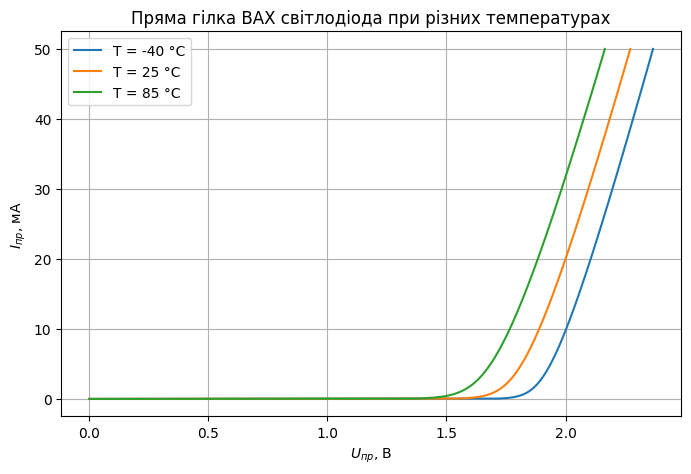

Uпр при Iпр:  -40 °C: 2.106 В,  25 °C: 2.000 В,  85 °C: 1.884 В
Температурний коефіцієнт прямої напруги ~= -1.78 мВ/°C


In [13]:
plt.figure(figsize=(8, 5))
vf_t = {}
for T in (-40, 25, 85):
    i_t, v_t = led_forward_iv(i_max=2.5 * I_led, temperature=T)
    vf_t[T] = np.interp(I_led, i_t, v_t)
    plt.plot(v_t, i_t * 1e3, label=f'T = {T} °C')
plt.xlabel('$U_{пр}$, В'); plt.ylabel('$I_{пр}$, мА')
plt.title('Пряма гілка ВАХ світлодіода при різних температурах')
plt.legend(); plt.grid(True)
plt.show()

tk = (vf_t[85] - vf_t[-40]) / 125
print('Uпр при Iпр:  ' + ',  '.join(f'{T} °C: {v:.3f} В' for T, v in vf_t.items()))
print(f'Температурний коефіцієнт прямої напруги ~= {tk*1e3:.2f} мВ/°C')

## Висновки

*(заповнюється студентом)*

1. Навести схему живлення світлодіода, розрахований і обраний з ряду E24 опір баластного резистора, потужності на резисторі, світлодіоді та споживану схемою потужність.
2. Вказати колір світіння і силу світла (світловий потік) світлодіода при розрахованому струмі.
3. Навести пряму гілку ВАХ у звичайному масштабі з побудовою дотичної 2–3 та значення $r_б$ і $\varphi_к$; пояснити, чому оцінка $r_б$ залежить від вибору точок 2 і 3 (розділ «Фізична перевірка $r_б$»).
4. Порівняти $\varphi_к$ з шириною забороненої зони матеріалу світлодіода; пояснити зв'язок кольору світіння і прямої напруги.
5. Пояснити вплив температури на пряму гілку ВАХ і на струм світлодіода в схемі з баластним резистором.

## Контрольні запитання

1. Приведіть класифікацію напівпровідникових діодів за їх призначенням.
2. Опишіть процеси в p-n переході за відсутності зовнішньої напруги.
3. Намалюйте ВАХ ідеального діода (p-n переходу).
4. Чим відрізняються ВАХ реального діода і p-n переходу?
5. Вплив температури навколишнього середовища на характеристики напівпровідникових діодів.

## Рекомендована література

1. Батушев В. А. Электронные приборы. — М.: Высш. шк., 1980. — 383 с.
2. Васильева Л. Д., Медведенко Б. І., Якименко Ю. І. Напівпровідникові прилади. — К.: ІВЦ «Політехніка», 2003. — 388 с.
3. Колонтаєвський Ю. П., Сосков А. Г. Електроніка і мікросхемотехніка: підручник. — К.: Каравела, 2007. — 384 с.
4. Пасынков В. В., Чиркин Л. К. Полупроводниковые приборы. — М.: Высшая школа, 1987. — 432 с.
5. Тугов Н. М., Глебов Б. А., Чарыков Н. А. Полупроводниковые приборы. — М.: Энергоатомиздат, 1990. — 576 с.
6. Электронные приборы / под ред. Г. Г. Шишкина. — М.: Энергоатомиздат, 1989. — 496 с.
7. Алехин В. А. Электротехника и электроника. Компьютерный лабораторный практикум в программной среде TINA-8. — М.: Горячая линия — Телеком, 2014. — 208 с.